In [2]:
# Importando os pacotes das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

[Treinamento] Ajustando Regressão Logística com StandardScaler...
=== MÉTRICAS DE AVALIAÇÃO (REGRESSÃO LOGÍSTICA) ===
Acurácia:  0.5699
AUC-ROC:   0.6274
F1-Score:  0.5409
Precisão:  0.4327
Recall:    0.7212

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           0       0.76      0.49      0.60       914
           1       0.43      0.72      0.54       495

    accuracy                           0.57      1409
   macro avg       0.60      0.60      0.57      1409
weighted avg       0.65      0.57      0.58      1409



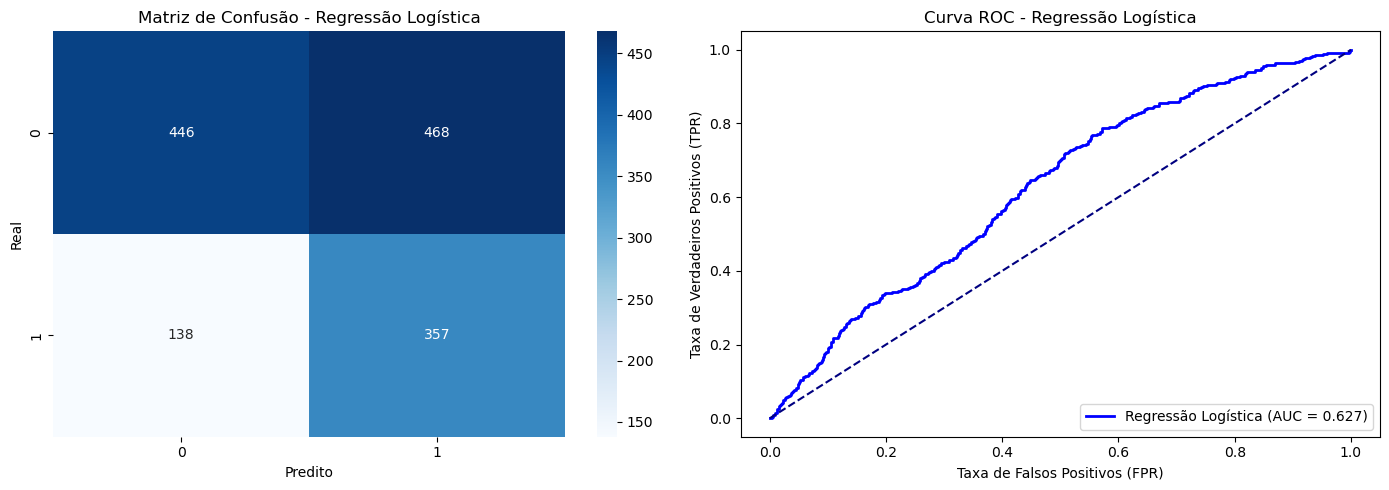

Modelo salvo em: ../models/logistic_regression_model.joblib


In [3]:
# 1. Carregamento dos Dados Processados
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# 2. Instanciação e Treinamento do Pipeline
print("[Treinamento] Ajustando Regressão Logística com StandardScaler...")
lr_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
)

lr_pipeline.fit(X_train, y_train)

# 3. Predição e Avaliação de Desempenho
# 3. Predição e Avaliação de Desempenho
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob_lr)
f1 = f1_score(y_test, y_pred_lr)
prec = precision_score(y_test, y_pred_lr)
rec = recall_score(y_test, y_pred_lr)

print("=== MÉTRICAS DE AVALIAÇÃO (REGRESSÃO LOGÍSTICA) ===")
print(f"Acurácia:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Precisão:  {prec:.4f}")
print(f"Recall:    {rec:.4f}\n")

print("Relatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred_lr))

# 4. Matriz de Confusão e Curva ROC
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusão - Regressão Logística')
ax[0].set_xlabel('Predito')
ax[0].set_ylabel('Real')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
ax[1].plot(fpr, tpr, label=f'Regressão Logística (AUC = {auc:.3f})', color='blue', lw=2)
ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
ax[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax[1].set_title('Curva ROC - Regressão Logística')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# 5. Salvando o Modelo Treinado
pasta_modelos = '../models/'
os.makedirs(pasta_modelos, exist_ok=True)
caminho_modelo = os.path.join(pasta_modelos, 'logistic_regression_model.joblib')
joblib.dump(lr_pipeline, caminho_modelo)
print(f"Modelo salvo em: {caminho_modelo}")

#### Análise dos Resultados da Regressão Logística

Com base nas métricas apresentadas, o modelo de Regressão Logística apresenta um desempenho modesto, com sinais claros de que ele prioriza encontrar os casos positivos (classe 1), mas sofre com muitos alarmes falsos.

#### 1. Principais Destaques das Métricas

* <b>Acurácia (0.5700):</b> O modelo acerta a previsão global em pouco mais da metade das vezes. Considerando que o conjunto de dados tem uma desproporção (914 amostras da classe 0 contra 495 da classe 1), uma acurácia de 57% está pouco acima de um palpite aleatório.
* <b>AUC-ROC (0.6274):</b> Indica uma capacidade discriminativa fraca a moderada. Um valor de 0.5 seria um modelo aleatório e 1.0 seria um modelo perfeito. O valor de 0.63 mostra que o modelo consegue separar parcialmente as classes, mas com bastante sobreposição.
* <b>Recall Alto para a Classe 1 (0.72):</b> O modelo é bom em "pescar" os casos positivos. Ele conseguiu identificar 72% de todos os exemplos reais da classe 1 ($358$ de $495$).
* <b>Precisão Baixa para a Classe 1 (0.43):</b> O grande calcanhar de Aquiles do modelo. De cada 10 previsões de que um caso era a classe 1, cerca de 6 estavam erradas (alarmes falsos). Isso ocorre porque o modelo previu a classe 1 com muita frequência, gerando muitos falsos positivos.

<hr>

#### 2. Visão Geral por Classe (Relatório Detalhado)

* <b>Classe 0 (Negativa / Maioritária):</b>
    * Possui uma precisão razoável (0,76), mas um recall menor (0,49), o que significa que o modelo deixa escapar muitos exemplos da classe 0 (confundindo-os com a classe 1).

* <b>Classe 1 (Positiva / Minoritária):</b>
    * Inverte a lógica: excelente recall (0,72), mas péssima precisão (0,43). O modelo é 'otimista' demais ao chutar a classe 1.